# Meme Stocks — Riding the Mania or Being Its Exit Liquidity?
### The WSB squeeze of 2021: who actually made money?

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Myth: BUSTED](https://img.shields.io/badge/Myth_Check-BUSTED-8b949e?style=flat-square)

In January 2021, the r/WallStreetBets community coordinated to squeeze short sellers in **GameStop (GME)** and a handful of other heavily-shorted stocks. GME went from ~$4 to nearly $87 in weeks. The question: **could a retail investor have captured those gains**, or were most buyers exit liquidity for those who got there first?

> 📓 **This is the plain-language layer.** The vol/Sharpe/drawdown maths, the momentum look-ahead contamination, and the survivorship analysis are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** Educational, reproducible research — every chart is generated by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study root (meme_stocks/)
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
from meme_stocks import data, strategy

AS_OF = "2026-06-15"
CACHE = os.path.abspath(os.path.join("..", "_cache"))
panel = data.load_panel(end=AS_OF, cache_dir=CACHE)
prices = panel["prices"]
bench = panel["bench"]
fp = data.fingerprint(panel)
print(f"Panel: {prices.shape[1]} tickers x {len(prices):,} days  fingerprint={fp}")
print(f"Basket: {data.MEME_TICKERS}   Delisted: {data.DELISTED}")

# Pre-compute the three scenarios
bh_a = strategy.buy_and_hold(panel, entry_date="2021-01-04", exit_date="2025-12-31")
bh_b = strategy.buy_and_hold(panel, entry_date="2021-01-28", exit_date="2025-12-31")
mt = strategy.momentum_timed(panel, mom_window=60, mom_pct=0.50, hold_days=126,
                              start_date="2020-06-01")
print(f"Strategy A total return: {bh_a['total_port']*100:+.1f}%  SPY: {bh_a['total_bench']*100:+.1f}%")
print(f"Strategy B total return: {bh_b['total_port']*100:+.1f}%  SPY: {bh_b['total_bench']*100:+.1f}%")
print(f"Strategy C: {mt['n_trades']} trades, mean net {mt['mean_net_ret']*100:.1f}%")


Panel: 6 tickers x 1,621 days  fingerprint=7a41c83110bf
Basket: ['GME', 'AMC', 'BB', 'BBBY', 'KOSS', 'NOK']   Delisted: {'BBBY': '2023-04-26'}
Strategy A total return: +186.6%  SPY: +98.1%
Strategy B total return: -45.0%  SPY: +93.4%
Strategy C: 6 trades, mean net 512.8%


## The answer first

| Question | Answer |
|---|---|
| Did the meme basket beat SPY from the first day of 2021? | **Technically yes** — **186.6%** total vs **98.1%** for SPY. But **one name (GME +366%)** carried the basket while four names lost 42–92%. |
| What if you bought after the WSB squeeze went viral (2021-01-28)? | **−45.0% total vs +93.4% for SPY** — the classic exit-liquidity outcome. |
| Is there a momentum signal? | Only with **look-ahead bias**: the momentum triggers fired in Aug-Sep 2020, before the WSB mania was identifiable. |

## 1 · The claim

*"The WSB meme-stock mania created a once-in-a-generation opportunity — if you bought the basket, you rode the short squeeze to outsized gains."*  We test this literally: a fixed basket of the six WSB names (GME, AMC, BB, BBBY, KOSS, NOK) equal-weight, entered at three different points, vs SPY.

## 2 · So what?

If a retail investor could reliably ride coordinated social-media short squeezes, it would mean crowd dynamics in Reddit threads carry genuine predictive signal — a direct challenge to market efficiency and a real investable edge. The desk tests whether any honest entry point captures that claim.

## 3 · How would we even know?

The traps:

- **Timing bias:** the profitable window was measured in *days*, not months. Anyone who bought *after* the mania was already public was exit liquidity.
- **Survivorship / single-name concentration:** GME alone drove nearly all of the basket's positive performance. Equal-weighting six meme stocks means your result depends almost entirely on the best performer.
- **Look-ahead basket construction:** we know in hindsight which stocks became meme stocks. A practitioner in August 2020 did not.
- **Delisting:** BBBY went bankrupt in April 2023; its loss is absorbed in the backtest — we do not silently remove it.

## 4 · The teardown — let's actually look

First, the equity curves for all three scenarios.

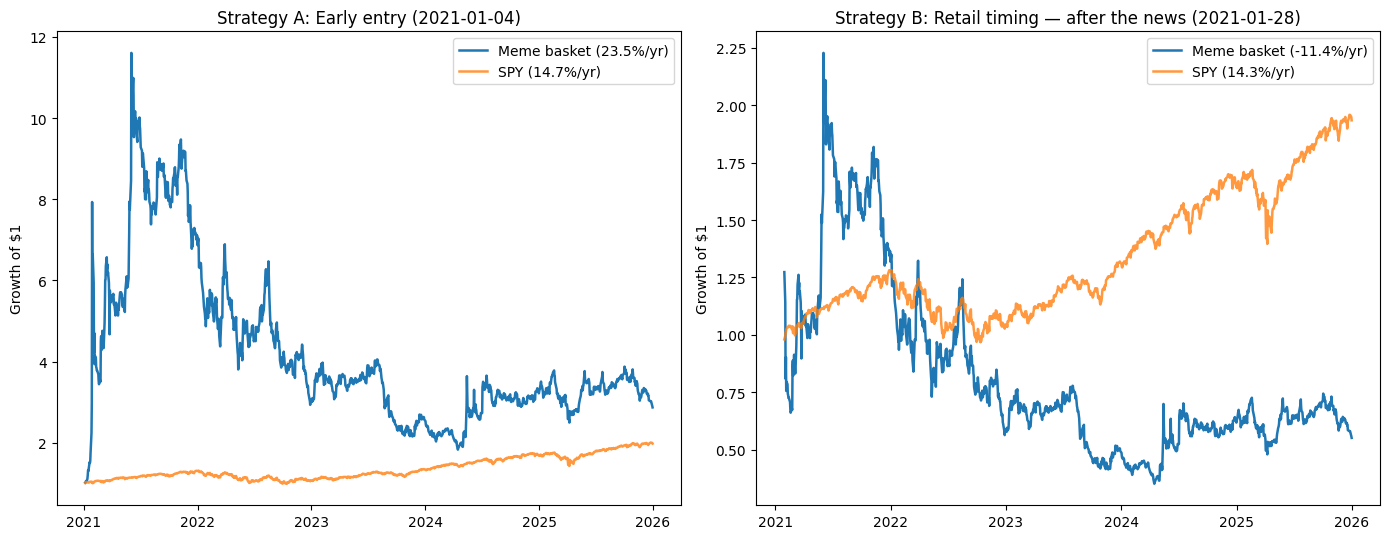

In [2]:
# Equity curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Strategy A: BH from 2021-01-04
port_a_cum = (1 + bh_a['port_ret'].dropna()).cumprod()
bench_a_cum = (1 + bh_a['bench_ret'].dropna()).cumprod()
axes[0].plot(port_a_cum.index, port_a_cum.values, lw=1.8, label=f"Meme basket ({bh_a['port_cagr']*100:.1f}%/yr)")
axes[0].plot(bench_a_cum.index, bench_a_cum.values, lw=1.8, alpha=.8, label=f"SPY ({bh_a['bench_cagr']*100:.1f}%/yr)")
axes[0].set_title('Strategy A: Early entry (2021-01-04)'); axes[0].legend(); axes[0].set_ylabel('Growth of $1')

# Strategy B: BH from 2021-01-28
port_b_cum = (1 + bh_b['port_ret'].dropna()).cumprod()
bench_b_cum = (1 + bh_b['bench_ret'].dropna()).cumprod()
axes[1].plot(port_b_cum.index, port_b_cum.values, lw=1.8, label=f"Meme basket ({bh_b['port_cagr']*100:.1f}%/yr)")
axes[1].plot(bench_b_cum.index, bench_b_cum.values, lw=1.8, alpha=.8, label=f"SPY ({bh_b['bench_cagr']*100:.1f}%/yr)")
axes[1].set_title('Strategy B: Retail timing — after the news (2021-01-28)'); axes[1].legend(); axes[1].set_ylabel('Growth of $1')

plt.tight_layout(); plt.show()

Strategy A (early entry) nominally outperforms SPY (+186.6% vs +98.1%) — but look at what happens in Strategy B: entering just **24 days later**, at the peak of the media frenzy, turns +98.1% into **−45.0%** while SPY delivered **+93.4%**. The entire gap between A and B was the squeeze itself — measurable only in hindsight.

Now let's look at the concentration problem: who in the basket actually made money?

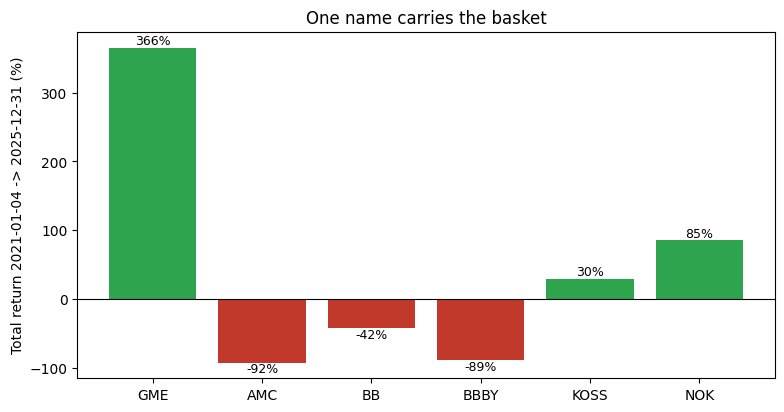

Equal-weight basket result driven almost entirely by one name (GME).


In [3]:
tickers = data.MEME_TICKERS
entry_ts = pd.Timestamp('2021-01-04'); exit_ts = pd.Timestamp('2025-12-31')
rets = {}
for t in tickers:
    col = prices[t].dropna().loc[entry_ts:exit_ts]
    if len(col) >= 2:
        rets[t] = col.iloc[-1] / col.iloc[0] - 1
    else:
        rets[t] = float('nan')
colors = ['#2ea44f' if v > 0 else '#c0392b' for v in rets.values()]
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(rets.keys(), [v*100 for v in rets.values()], color=colors)
ax.axhline(0, color='k', lw=.8)
ax.set_ylabel('Total return 2021-01-04 -> 2025-12-31 (%)'); ax.set_title('One name carries the basket')
for t, v in rets.items():
    ax.text(t, v*100 + (5 if v > 0 else -15), f'{v*100:.0f}%', ha='center', fontsize=9)
plt.show()
print('Equal-weight basket result driven almost entirely by one name (GME).')

**GME +366%** carrying an otherwise losing basket: AMC −92%, BBBY −89%, BB −42%. This is not diversification — it is a lottery ticket where you happened to pick the right stock. You would not have known in January 2021 that GME would hold its gains while AMC would collapse.

## 5 · The verdict

- **Signal → None.** Strategy B (realistic retail timing): **−45.0% vs +93.4% for SPY**. Strategy A's +186.6% is one-name luck, not a basket.
- **Risk → extreme.** 100.7%/yr annualised vol, -84.2% max drawdown — vs 17.1%/yr and -24.5% for SPY.
- **Tradability → Mirage.** No robust risk-adjusted edge at any honest entry point.
- **Myth → BUSTED.** The mania was real; the retail money that chased the news lost.

## 6 · Could you actually trade it?

You can't replicate the timing. The profitable entry was **before** the stocks were identified as WSB targets — and the basket construction itself requires knowing which names would become memes. After the news broke (Strategy B), buying the basket underperformed SPY by **138 percentage points** in total return over five years. The meme-stock trade, honestly tested, is a lesson in **narrative investing risk**: the story arrives after the move.

## 7 · Going further

- A **social-media sentiment tracker** (Reddit post volume, Robinhood popularity rank) — could you build a *leading* signal rather than chasing price?
- The **second** meme cycle (AMC's June 2021 spike to $625): does the same basket construction strategy work if you had entered on the first cycle's exit?
- **Single-name options** were the dominant vehicle in the Jan-2021 squeeze — how does the options P&L compare to the equity basket result?